In [1]:
import numpy as np
import matplotlib.pyplot as plt

RuntimeError: module compiled against API version 0xe but this version of numpy is 0xd

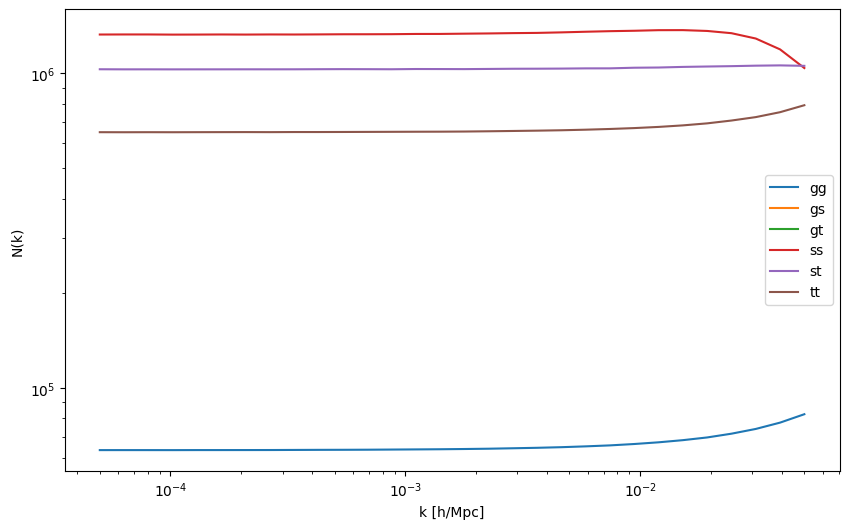

In [2]:
import pandas as pd

# Load results
df = pd.read_pickle('../output/desiasymm/data_dir/quadratic_results.pkl')

# Access specific results
k_values = df['K']

# Plot results
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
r = {}

tr1, tr2 = "gal", "gal2"
for estimator_pair in ['gg', 'gs', 'gt', 'ss', 'st', 'tt']:
    key = f"{estimator_pair}_{tr1}{tr2}"
    if key in df:
        plt.loglog(df['K'], df[key]**-1., label=estimator_pair)
        r[estimator_pair] = (df['K'], df[key]**-1.)
plt.legend()
plt.xlabel('k [h/Mpc]')
plt.ylabel('N(k)')
plt.show()

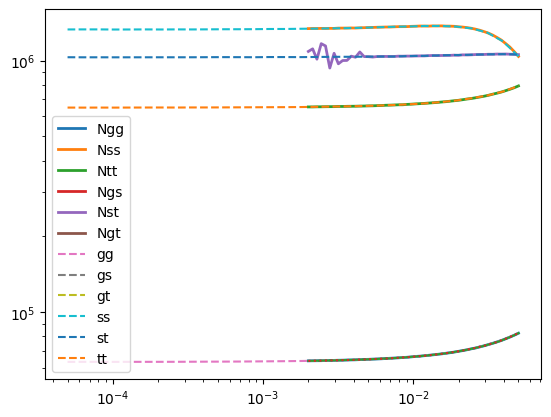

In [3]:
nomi = ["desi", "desiasymm"]
nomi = ["desiasymm"]

kk, nn = np.loadtxt("../output/desiasymm/data_dir/Ngg.txt").T
knew, nnew = np.loadtxt("../Ngg_new.txt").T

for i, nome in enumerate(nomi):
    directory = f"/home/users/d/darwish/quadraticrecforlss/example/output/{nome}/data_dir/"
    Ns = {k: np.loadtxt(directory+f"{k}.txt").T for k in ["Ngg", "Nss", "Ntt", "Ngs", "Nst", "Ngt"]}
    vals = {k: np.loadtxt(directory+f"values{k}.txt").T for k in ["gg", "ss", "tt"]}

    linear_power = np.loadtxt(directory+"linear_power.txt").T
    nonlinear_power = np.loadtxt(directory+"nonlinear_power.txt").T

    for k, v in Ns.items():
        K, N = v
        plt.loglog(K, N, lw = 2, label = k if i == 0 else None, ls = "--" if i > 0 else "-")

power = np.interp(K, linear_power[0], linear_power[1])
#plt.plot(K, power, lw = 2, color = "black", label = "Linear Matter Power Spectrum")


"""for k in vals.keys():
    K, alpha_ab_beta_ab, alpha_ab_beta_ba, alpha_ba_beta_ab, alpha_ba_beta_ba = vals[k]
    X = (alpha_ab_beta_ab+alpha_ab_beta_ba+alpha_ba_beta_ab+alpha_ba_beta_ba)
    plt.loglog(K, X**-1., ls = "--")"""


for k in r.keys():
    plt.loglog(*r[k], ls = "--", label = k)
    
plt.plot(kk, nn**-1)
plt.plot(knew, nnew, ls = ":")


plt.legend()

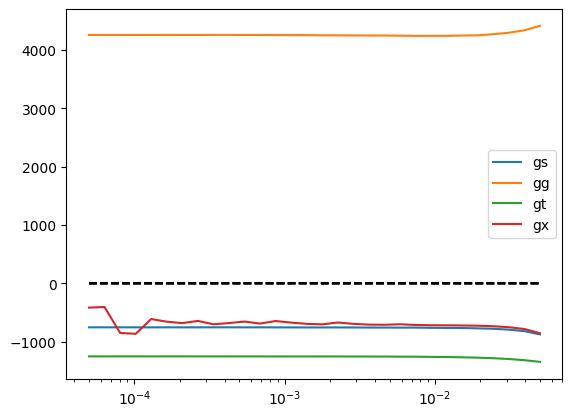

In [4]:
df = pd.read_pickle('../output/desiasymm/data_dir/quadratic_results.pkl')

all_alpha = ["s", "g", "t", "x"]
alpha = "g"
estimator_pairs = [f"{alpha}{beta}" if beta != "g" else f"{beta}{alpha}" for beta in all_alpha]
estimator_pair = f"{alpha}{alpha}"
key = f"{estimator_pair}_{tr1}{tr2}"
Naa = df[key]**-1.


for estimator_pair in estimator_pairs:
    key_bias = f"{estimator_pair}_{tr1}"
    bias = df[key_bias]
    key_var = f"{estimator_pair}_{tr1}{tr2}"
    plt.plot(df['K'], bias*Naa, label = estimator_pair)
    Ninv = df[key_var]
    plt.plot(df['K'], Ninv*Naa, ls = "--", color = "black")
plt.legend()
plt.xscale("log")
plt.show()

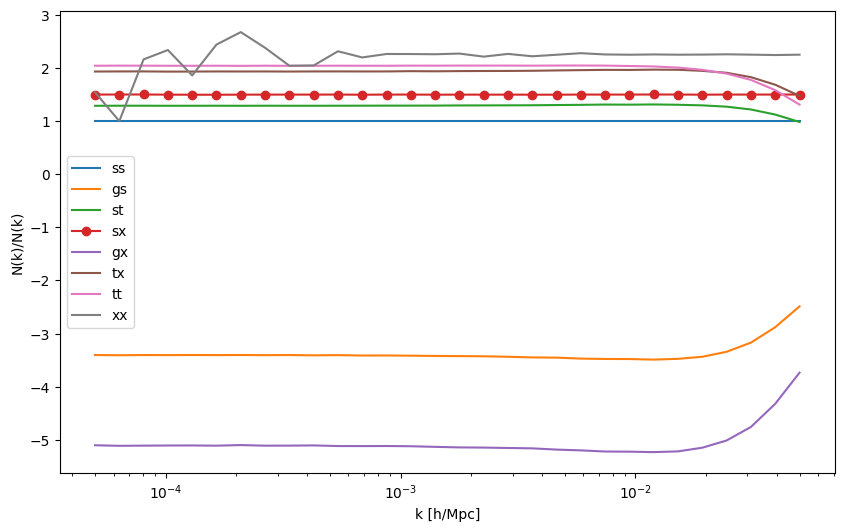

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
df = pd.read_pickle('../output/desiasymm/data_dir/quadratic_results.pkl')
for estimator_pair in ['ss', 'gs', 'st', 'sx', 'gx', 'tx', 'tt', 'xx']:
    key = f"{estimator_pair}_{tr1}{tr2}"
    if key in df:
        if estimator_pair == "ss":
            Naa = df[key]**-1.
        plt.plot(df['K'], (Naa*df[key]), label=estimator_pair, marker = "o" if 'sx' in estimator_pair else None)
plt.legend()
plt.xlabel('k [h/Mpc]')
plt.ylabel('N(k)/N(k)')
plt.xscale("log")
plt.show()

In [6]:
from scipy.interpolate import UnivariateSpline
from scipy.integrate import quad

knl, pnl = nonlinear_power
pnlf = UnivariateSpline(knl, pnl)

kl, pl = linear_power
plf = UnivariateSpline(knl, pl)
plf_loglog = UnivariateSpline(np.log(knl), np.log(pl))
pldf = plf_loglog.derivative(1)

fss = lambda k: k**2*plf(k)**2/pnlf(k)**2*(0.5+1/3*pldf(k))
fsg = lambda k: k**2*plf(k)**2/pnlf(k)**2*(-1-2/3*pldf(k))
fgg = lambda k: k**2*plf(k)**2/pnlf(k)**2

factor_ss = quad(fss, 0.051, 0.15)[0]
factor_sg = quad(fsg, 0.051, 0.15)[0]
factor_gg = quad(fgg, 0.051, 0.15)[0]
print(factor_sg/factor_ss, factor_ss/factor_sg)


b10 = 1.6
facss = factor_ss/b10**4*(2*np.pi)/(2*np.pi)**3*2

facgg = factor_gg/b10**4*(2*np.pi)/(2*np.pi)**3*2*2*8*(17/21)**2


-2.0 -0.5


In [23]:
import s
from sympy import symbols

def F_S(k1, k2, k1_mag, k2_mag, dot_product):
    return (1/2) * (1/k1_mag**2 + 1/k2_mag**2) * dot_product

def F_T(k1, k2, k1_mag, k2_mag, dot_product):
    return dot_product**2/(k1_mag**2*k2_mag**2) - 1/3

def F_G(k1, k2, k1_mag, k2_mag, dot_product):
    return k2_mag/k2_mag*17/21  # This is just 1, but keeping your original function

Ma, Mb = symbols('M_a M_b')

cases = {"S": (F_S, 1, 1), "T": (F_T, 1, 1), "G": (F_G, 1, 1), "X": (F_S, Ma, Mb)}

fixed = "G"
vary = ["G"] #["S", "T", "G", "X"]

K, k, mu, P_k, Q_k = symbols('K k mu P_k Q_k')

results = {}
results_latex = {}
for v in vary:
    result = s.calculate_squeezed_limit_with_integration(cases[fixed][0], cases[v][0], take_squeezed_limit = False, Ma1 = cases[fixed][1], Mb1 = cases[fixed][2], Ma2 = cases[v][1], Mb2 = cases[v][2], K = K, k = k, mu = mu, P_k = P_k, Q_k = Q_k)
    print(f"\n{fixed} * {v} squeezed limit with k² and μ integration:")
    result = s.final_integrand(result)
    #result = float_to_rational(result)
    print(result)
    results[f"{fixed}-{v}"] = result

Print -34*K*P_k*Q_k*mu/(21*k) + 68*P_k/21
MU INTEGRATED -1156*P_k**2*Q_k**2/(441*P_nlin**2*Q_nlin**2*b_AA**2*b_BB**2) + 4624*P_k**2*Q_k/(441*P_nlin**2*Q_nlin*b_AA**2*b_BB**2) + 578*P_k**2*k*(Q_k - 2*Q_nlin)**2*log(-K*Q_nlin - k)/(441*K*P_nlin**2*Q_nlin**3*b_AA**2*b_BB**2) - 578*P_k**2*k*(Q_k - 2*Q_nlin)**2*log(K*Q_nlin - k)/(441*K*P_nlin**2*Q_nlin**3*b_AA**2*b_BB**2)

G * G squeezed limit with k² and μ integration:
289*P_k**2*k**2*(2*K*Q_k*Q_nlin*(-Q_k + 4*Q_nlin) + k*(Q_k**2*(log(-K*Q_nlin - k) - log(K*Q_nlin - k)) + 4*Q_k*Q_nlin*(-log(-K*Q_nlin - k) + log(K*Q_nlin - k)) + 4*Q_nlin**2*(log(-K*Q_nlin - k) - log(K*Q_nlin - k))))/(882*K*P_nlin**2*Q_nlin**3*b_AA**2*b_BB**2*pi**2)


In [24]:
from sympy import symbols, lambdify
import numpy as np
from scipy.interpolate import UnivariateSpline
from scipy.integrate import quad

def evaluate_result(expr, linear_power, nonlinear_power, k_range=(0.01, 1.0), 
                   K_value=1e-4, bA=1.0, bB=1.0, Ma=1.0, Mb=1.0):
    """
    Evaluate a symbolic result using numerical power spectra, properly handling 1/K terms
    
    Parameters:
    -----------
    expr : sympy expression
        The symbolic expression to evaluate
    linear_power : tuple
        (k_array, P_L_array) for the linear power spectrum
    nonlinear_power : tuple
        (k_array, P_NL_array) for the nonlinear power spectrum
    k_range : tuple
        (k_min, k_max) for the integration range
    K_value : float
        Small value to use for K in 1/K terms
    bA, bB : float
        Bias parameters
    Ma, Mb : float
        Multiplier parameters
        
    Returns:
    --------
    tuple: (result, error) from numerical integration
    """
    # Define symbols for lambdify
    k, K = symbols('k K')
    P_k, P_nlin = symbols('P_k P_nlin')  # Power spectra
    Q_k, Q_nlin = symbols('Q_k Q_nlin')  # Derivatives
    b_AA, b_BB = symbols('b_AA b_BB')    # Bias parameters
    Ma_sym, Mb_sym = symbols('Ma Mb')    # Multiplier parameters
    pi = symbols('pi')
    
    # Create lambda function for the expression
    func = lambdify([k, K, P_k, P_nlin, Q_k, Q_nlin, b_AA, b_BB, Ma_sym, Mb_sym, pi], 
                   expr, modules=['numpy'])
    
    # Extract arrays
    knl, pnl = nonlinear_power
    kl, pl = linear_power
    
    # Create spline interpolations for power spectra
    pnlf = UnivariateSpline(knl, pnl, s=0)
    plf = UnivariateSpline(kl, pl, s=0)
    
    # Create log-log splines for derivatives
    plf_loglog = UnivariateSpline(np.log(kl), np.log(pl), s=0)
    pnlf_loglog = UnivariateSpline(np.log(knl), np.log(pnl), s=0)
    
    # Define the integrand function
    def integrand(k_val):
        # Evaluate power spectra at k
        P_L = plf(k_val)
        P_NL = pnlf(k_val)
        
        # Evaluate logarithmic derivatives
        dln_P_L_dlnk = plf_loglog.derivative(1)(np.log(k_val))
        dln_P_NL_dlnk = pnlf_loglog.derivative(1)(np.log(k_val))
        
        # Evaluate the lambda function
        return func(k_val, K_value, P_L, P_NL, dln_P_L_dlnk, dln_P_NL_dlnk, 
                   bA, bB, Ma, Mb, np.pi)
    
    # Perform the integration
    k_min, k_max = k_range
    result, error = quad(integrand, k_min, k_max)
    
    return result, error


In [25]:
knl, pnl = nonlinear_power
kl, pl = linear_power

In [26]:
results["G-G"]

289*P_k**2*k**2*(2*K*Q_k*Q_nlin*(-Q_k + 4*Q_nlin) + k*(Q_k**2*(log(-K*Q_nlin - k) - log(K*Q_nlin - k)) + 4*Q_k*Q_nlin*(-log(-K*Q_nlin - k) + log(K*Q_nlin - k)) + 4*Q_nlin**2*(log(-K*Q_nlin - k) - log(K*Q_nlin - k))))/(882*K*P_nlin**2*Q_nlin**3*b_AA**2*b_BB**2*pi**2)

In [27]:
check = []
bA, bB = 1.6, 1.6
for K in df['K']:
    r = evaluate_result(results["G-G"], linear_power, nonlinear_power, k_range=(0.051, 0.15), 
                    K_value=K, bA=bA, bB=bB, Ma=1.0, Mb=1.0)[0]
    check.append(r)
check = np.array(check)


<lambdifygenerated-121>:2: RuntimeWarning: invalid value encountered in log
  return (289/882)*P_k**2*k**2*(2*K*Q_k*Q_nlin*(-Q_k + 4*Q_nlin) + k*(Q_k**2*(log(-K*Q_nlin - k) - log(K*Q_nlin - k)) + 4*Q_k*Q_nlin*(-log(-K*Q_nlin - k) + log(K*Q_nlin - k)) + 4*Q_nlin**2*(log(-K*Q_nlin - k) - log(K*Q_nlin - k))))/(K*P_nlin**2*Q_nlin**3*b_AA**2*b_BB**2*pi**2)
/tmp/ipykernel_3949005/1756123637.py:72: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  result, error = quad(integrand, k_min, k_max)
<lambdifygenerated-122>:2: RuntimeWarning: invalid value encountered in log
  return (289/882)*P_k**2*k**2*(2*K*Q_k*Q_nlin*(-Q_k + 4*Q_nlin) + k*(Q_k**2*(log(-K*Q_nlin - k) - log(K*Q_nlin - k)) + 4*Q_k*Q_nlin*(-log(-K*Q_nlin - k) + log(K*Q_nlin - k)) + 4*Q_nlin**2*(log(-K*Q_nlin - k) - log(K*Q_nlin - k))))/(K*P_nlin**2*Q_nlin**3*b_AA**2*b_BB**2*pi**2)
<lambdifygenerated-123>:2: RuntimeWar

In [28]:
results["G-G"]

289*P_k**2*k**2*(2*K*Q_k*Q_nlin*(-Q_k + 4*Q_nlin) + k*(Q_k**2*(log(-K*Q_nlin - k) - log(K*Q_nlin - k)) + 4*Q_k*Q_nlin*(-log(-K*Q_nlin - k) + log(K*Q_nlin - k)) + 4*Q_nlin**2*(log(-K*Q_nlin - k) - log(K*Q_nlin - k))))/(882*K*P_nlin**2*Q_nlin**3*b_AA**2*b_BB**2*pi**2)

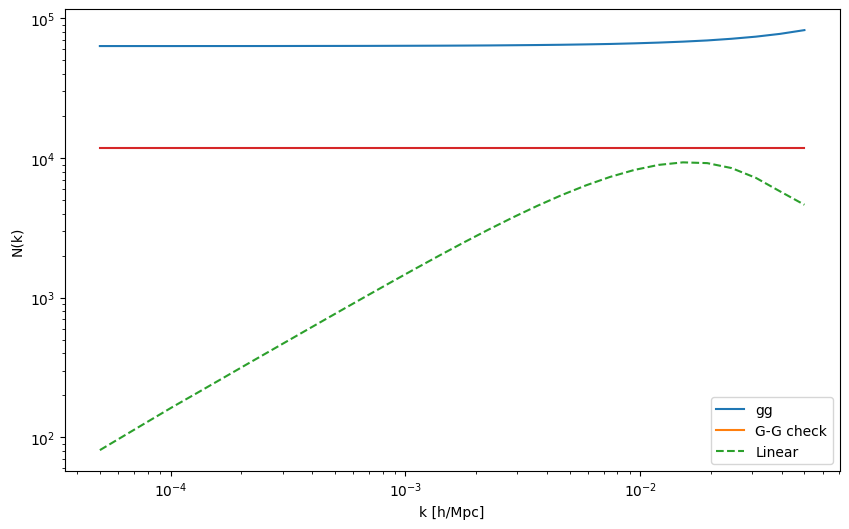

In [30]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
df = pd.read_pickle('../output/desiasymm/data_dir/quadratic_results.pkl')
for estimator_pair in ['gg']:
    key = f"{estimator_pair}_{tr1}{tr2}"
    Naa = df[key]**-1.
    plt.loglog(df['K'], Naa, label=estimator_pair, marker = "o" if 'sx' in estimator_pair else None)
plt.plot(df['K'], (check)**-1., label = "G-G check")
plt.plot(df['K'], np.interp(df['K'], kl, pl), label = "Linear", ls = "--")
plt.plot(df['K'], np.ones_like(df['K'])*facgg**-1.)
plt.legend()
plt.xlabel('k [h/Mpc]')
plt.ylabel('N(k)')
plt.xscale("log")
plt.show()

In [9]:
D = np.load(directory+f"valuesss.npy", allow_pickle=True).item()

/tmp/ipykernel_2027098/494001731.py:20: RuntimeWarning: divide by zero encountered in reciprocal
  plt.plot(K, total_eq**-1., color = "black")


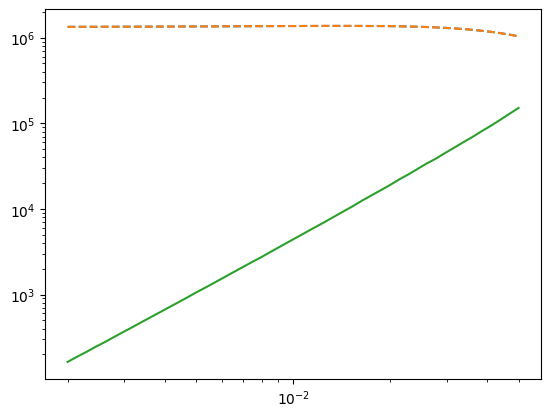

In [11]:
K, alpha_ab_beta_ab, alpha_ab_beta_ba, alpha_ba_beta_ab, alpha_ba_beta_ba = vals["ss"]
X = (alpha_ab_beta_ab+alpha_ab_beta_ba+alpha_ba_beta_ab+alpha_ba_beta_ba)
plt.loglog(K, X**-1., ls = "--")
y = X**-1.
lista = ["alpha_ab_beta_ab", "alpha_ab_beta_ba", "alpha_ba_beta_ab", "alpha_ba_beta_ba"]
s1, s2 = "m", "m"
X = np.sum([D[l+f"_{s1+s2}"] for l in lista], axis = 0)
plt.loglog(K, X**-1., ls = "--")

fmm_1 = D["alpha_ab_beta_ab_mm"]+D["alpha_ab_beta_ab_mm"]
fmm_2 = D["alpha_ab_beta_ba_mm"]+D["alpha_ab_beta_ba_mm"]
b_1 = 0
b_2 = 2
total = b_1*fmm_1+b_2*fmm_2
#total *= 5/3*4e-3
plt.plot(K, -total**-1.)

total_eq = b_1*fmm_1+b_1*fmm_2
#total_eq *= 5/3*4e-3
plt.plot(K, total_eq**-1., color = "black")

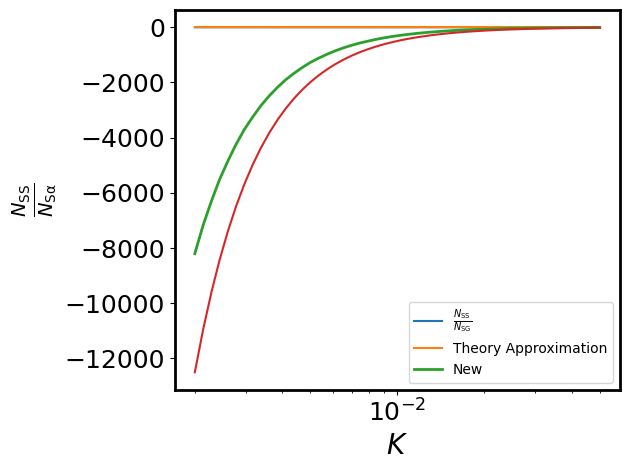

In [12]:
key = "s"
lista = Ns.keys()
lista = ["Ngs"]
somma = np.sum([Ns[f"N{key}{key}"][-1]/Ns[k][-1] for k in lista if key in k], axis = 0)
plt.plot(K, somma, label = r"$\frac{N_{\mathrm{SS}}}{N_{\mathrm{SG}}}$")
plt.plot(K, K*0-4*17/21, label = "Theory Approximation")

total = 0*fmm_1+b_2*fmm_2
plt.plot(K, total*Ns[f"N{key}{key}"][-1], lw = 2, label = "New")
plt.plot(K, -1/K**2*0.5e-1)

#plt.plot(K, total_eq*Ns[f"N{key}{key}"][-1], lw = 1, label = "New with same biases", color = "black", ls = "--")

#lista = ["Ngt"]
#somma = np.sum([Ns[f"N{key}{key}"][-1]/Ns[k][-1] for k in lista if key in k], axis = 0)
#plt.loglog(K, abs(somma))
plt.tick_params(labelsize = 18)
plt.xscale("log")
plt.xlabel(r"$K$", fontsize = 20)
# Get the current axes
ax = plt.gca()  # gca stands for "get current axes"

# Make the frame (spines) thicker
for spine in ax.spines.values():
    spine.set_linewidth(2.)  # Adjust thickness as needed (2.5 is quite thick)

plt.ylabel(r"$\frac{N_{\mathrm{SS}}}{N_{\mathrm{S\alpha}}}$", fontsize = 20)
#plt.ylim(-10, 5)
plt.legend()
plt.tight_layout()
plt.savefig("bias_trend.pdf", dpi = 300)

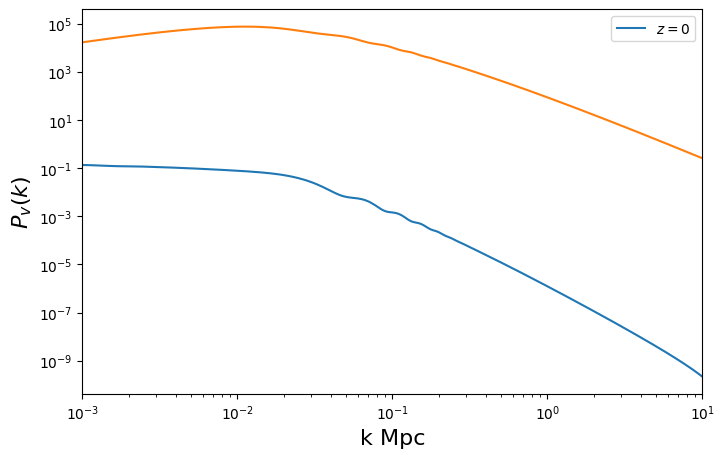

In [15]:
import camb
from camb import model
#from nbodykit.lab import *
#import nbodykit
#cosmo = cosmology.Planck15

kmax=10 
k_per_logint = 30
zs = [0]#, 3, 10, 200, 500,800, 1090]

pars = camb.CAMBparams()
pars.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122)
pars.InitPower.set_params(ns=0.965)
pars.WantTransfer = True
pars.set_matter_power(redshifts=zs, kmax=kmax, k_per_logint=k_per_logint, silent=True)
results = camb.get_results(pars)

PKint = results.get_matter_power_interpolator(nonlinear=False, 
    hubble_units=False, k_hunit=False, 
    var1=model.Transfer_tot, var2=model.Transfer_vel_baryon_cdm)

plt.figure(figsize=(8,5))
ks = np.logspace(-3, np.log10(kmax), 300)
for i, z in enumerate(zs):
     curlyP = PKint.P(z,ks)
     plt.semilogx(ks, curlyP)

PKint = results.get_matter_power_interpolator(nonlinear=False, 
    hubble_units=False, k_hunit=False, 
    var1=model.Transfer_tot, var2=model.Transfer_tot)

for i, z in enumerate(zs):
     curlyP = PKint.P(z,ks)
     plt.semilogx(ks, curlyP)
    
plt.xlim([1e-3,kmax])
plt.xlabel('k Mpc', fontsize=16)
plt.ylabel(r'$P_v(k)$', fontsize=16)
plt.yscale("log")
plt.legend(['$z = %s$'%z for z in zs]);